In [2]:
import pandas as pd

In [12]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 93.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 89.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd

def df_to_score(df: pd.DataFrame) -> float:
    sign = df["decision"].map({"buy": 1, "sell": -1})
    return (df["score"] * sign).sum()
def ticker_stats(df: pd.DataFrame) -> pd.DataFrame:
    # map decisions to +1 / -1
    sign = df["decision"].map({"buy": 1, "sell": -1})
    
    if sign.isna().any():
        raise ValueError("Invalid decision values detected")

    # profit contribution per row
    profit = df["score"] * sign
    
    # correctness: decision aligns with score direction
    correct = ((df["score"] > 0) & (df["decision"] == "buy")) | \
              ((df["score"] < 0) & (df["decision"] == "sell"))

    df = df.copy()
    df["profit"] = profit
    df["correct"] = correct

    # aggregate per ticker
    result = df.groupby("ticker").agg(
        correct_pct=("correct", "mean"),
        total_profit=("profit", "sum"),
        n=("ticker", "size")
    )

    return result

In [41]:
import matplotlib.pyplot as plt

def plot_ticker_stats(stats_df):
    fig, ax = plt.subplots()

    ax.scatter(stats_df["correct_pct"], stats_df["total_profit"])

    # label points with ticker
    for ticker, row in stats_df.iterrows():
        ax.annotate(ticker, (row["correct_pct"], row["total_profit"]))

    ax.set_xlabel("Correct Decision %")
    ax.set_ylabel("Total Profit")
    ax.set_title("Ticker Performance: Accuracy vs Profit")

    plt.show()
def plot_profit_bar(stats_df):
    stats_df["total_profit"].plot(kind="bar")
    plt.xlabel("Ticker")
    plt.ylabel("Total Profit")
    plt.title("Profit by Ticker")
    plt.show()
def plot_accuracy_bar(stats_df):
    stats_df["correct_pct"].plot(kind="bar")
    plt.xlabel("Ticker")
    plt.ylabel("Correct Decision %")
    plt.title("Accuracy by Ticker")
    plt.show()

def plot_accuracy_with_score_distribution(df: pd.DataFrame, stats_df: pd.DataFrame):
    # compute positive / negative percentages per ticker
    dist = df.copy()
    dist["is_pos"] = dist["score"] > 0
    dist["is_neg"] = dist["score"] < 0

    dist_agg = dist.groupby("ticker").agg(
        pos_pct=("is_pos", "mean"),
        neg_pct=("is_neg", "mean")
    )

    # align with stats_df index
    merged = stats_df.join(dist_agg)

    # ensure consistent order
    merged = merged.sort_index()

    fig, ax1 = plt.subplots()

    # bar chart: correct %
    merged["correct_pct"].plot(kind="bar", ax=ax1)
    ax1.set_ylabel("Correct Decision %")
    ax1.set_xlabel("Ticker")

    # second axis for overlays
    ax2 = ax1.twinx()

    ax2.plot(merged.index, merged["pos_pct"], marker='o')
    ax2.plot(merged.index, merged["neg_pct"], marker='o')

    ax2.set_ylabel("Score Distribution %")

    ax1.set_title("Accuracy with Score Distribution Overlay")

    plt.show()


def plot_buy_sell_pct(df: pd.DataFrame):
    # compute percentages per ticker
    dist = df.copy()
    dist["is_buy"] = dist["decision"] == "buy"
    dist["is_sell"] = dist["decision"] == "sell"

    agg = dist.groupby("ticker").agg(
        buy_pct=("is_buy", "mean"),
        sell_pct=("is_sell", "mean")
    )

    # plot
    fig, ax = plt.subplots()

    x = range(len(agg))
    width = 0.4

    ax.bar(x, agg["buy_pct"], width=width)
    ax.bar([i + width for i in x], agg["sell_pct"], width=width)

    ax.set_xticks([i + width / 2 for i in x])
    ax.set_xticklabels(agg.index)

    ax.set_xlabel("Ticker")
    ax.set_ylabel("Percentage")
    ax.set_title("Buy vs Sell Percentage per Ticker")

    plt.show()

def plot_buy_sell_overall(df: pd.DataFrame):
    pct = df["decision"].value_counts(normalize=True)

    pct.plot(kind="bar")
    plt.ylabel("Percentage")
    plt.title("Overall Buy vs Sell Distribution")

    plt.show()

def plot_decision_vs_score_overlay(df: pd.DataFrame):
    d = df.copy()

    # decision indicators
    d["is_buy"] = d["decision"] == "buy"
    d["is_sell"] = d["decision"] == "sell"

    # actual signal indicators
    d["is_pos"] = d["score"] > 0
    d["is_neg"] = d["score"] < 0

    # aggregate per ticker
    agg = d.groupby("ticker").agg(
        buy_pct=("is_buy", "mean"),
        sell_pct=("is_sell", "mean"),
        pos_pct=("is_pos", "mean"),
        neg_pct=("is_neg", "mean"),
    ).sort_index()

    x = range(len(agg))
    width = 0.35

    fig, ax1 = plt.subplots()

    # bars: decisions
    ax1.bar(x, agg["buy_pct"], width=width)
    ax1.bar([i + width for i in x], agg["sell_pct"], width=width)

    ax1.set_xticks([i + width / 2 for i in x])
    ax1.set_xticklabels(agg.index)
    ax1.set_ylabel("Decision %")

    # overlay lines: actual signal distribution
    ax2 = ax1.twinx()

    ax2.plot([i + width / 2 for i in x], agg["pos_pct"], marker='o')
    ax2.plot([i + width / 2 for i in x], agg["neg_pct"], marker='o')

    ax2.set_ylabel("Score Distribution %")

    ax1.set_title("Decision vs Actual Signal Distribution")

    plt.show()

def plot_pnl_over_time(df: pd.DataFrame, cumulative=True):
    d = df.copy()

    # map decisions to +1 / -1
    sign = d["decision"].map({"buy": 1, "sell": -1})
    if sign.isna().any():
        raise ValueError("Invalid decision values")

    # profit per row
    d["profit"] = d["score"] * sign

    # convert month string to number
    d["month_num"] = pd.to_datetime(d["month"], format="%b").dt.month

    # build datetime
    d["date"] = pd.to_datetime(
        dict(year=d["year"], month=d["month_num"], day=d["day"])
    )

    # aggregate daily profit
    daily = d.groupby("date")["profit"].sum().sort_index()

    if cumulative:
        daily = daily.cumsum()

    # plot
    plt.figure()
    plt.plot(daily.index, daily.values)

    plt.xlabel("Date")
    plt.ylabel("Cumulative Profit" if cumulative else "Daily Profit")
    plt.title("PnL Over Time")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_pnl_by_ticker(df: pd.DataFrame, cumulative=True):
    d = df.copy()

    # map decisions to +1 / -1
    sign = d["decision"].map({"buy": 1, "sell": -1})
    if sign.isna().any():
        raise ValueError("Invalid decision values")

    # profit per row
    d["profit"] = d["score"] * sign

    # convert month string to numeric
    d["month_num"] = pd.to_datetime(d["month"], format="%b").dt.month

    # build datetime
    d["date"] = pd.to_datetime(
        dict(year=d["year"], month=d["month_num"], day=d["day"])
    )

    # aggregate per ticker per day
    grouped = (
        d.groupby(["ticker", "date"])["profit"]
        .sum()
        .sort_index()
    )

    fig, ax = plt.subplots()

    # plot each ticker separately
    for ticker in grouped.index.get_level_values(0).unique():
        ts = grouped.loc[ticker]

        if cumulative:
            ts = ts.cumsum()

        ax.plot(ts.index, ts.values, label=ticker)

    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Profit" if cumulative else "Daily Profit")
    ax.set_title("PnL Over Time by Ticker")

    ax.legend()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_pnl_buy_only(df: pd.DataFrame, cumulative=True):
    d = df.copy()

    # keep only buys
    d = d[d["decision"] == "buy"].copy()

    # profit = score (since always long)
    d["profit"] = d["score"]

    # convert month string to numeric
    d["month_num"] = pd.to_datetime(d["month"], format="%b").dt.month

    # build datetime
    d["date"] = pd.to_datetime(
        dict(year=d["year"], month=d["month_num"], day=d["day"])
    )

    # aggregate per ticker per day
    grouped = (
        d.groupby(["ticker", "date"])["profit"]
        .sum()
        .sort_index()
    )

    fig, ax = plt.subplots()

    for ticker in grouped.index.get_level_values(0).unique():
        ts = grouped.loc[ticker]

        if cumulative:
            ts = ts.cumsum()

        ax.plot(ts.index, ts.values, label=ticker)

    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Profit" if cumulative else "Daily Profit")
    ax.set_title("PnL Over Time by Ticker (Buy Only)")

    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_pnl_difference(df: pd.DataFrame, cumulative=True):
    d = df.copy()

    # --- FULL STRATEGY ---
    sign = d["decision"].map({"buy": 1, "sell": -1})
    if sign.isna().any():
        raise ValueError("Invalid decision values")

    d["profit_full"] = d["score"] * sign

    # --- BUY ONLY ---
    d["profit_buy"] = 0.0
    d.loc[d["decision"] == "buy", "profit_buy"] = d["score"]

    # --- DATE CONSTRUCTION ---
    d["month_num"] = pd.to_datetime(d["month"], format="%b").dt.month
    d["date"] = pd.to_datetime(
        dict(year=d["year"], month=d["month_num"], day=d["day"])
    )

    # --- AGGREGATE ---
    grouped = d.groupby(["ticker", "date"]).agg(
        full=("profit_full", "sum"),
        buy=("profit_buy", "sum")
    ).sort_index()

    fig, ax = plt.subplots()

    for ticker in grouped.index.get_level_values(0).unique():
        ts = grouped.loc[ticker]

        diff = ts["full"] - ts["buy"]

        if cumulative:
            diff = diff.cumsum()

        ax.plot(diff.index, diff.values, label=ticker)

    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Difference (Full - Buy Only)" if cumulative else "Daily Difference")
    ax.set_title("PnL Difference: Full Strategy vs Buy Only (Short Contribution)")

    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
def plot_pnl_comparison(dfs, labels=None, cumulative=True):
    """
    Plot cumulative (or daily) PnL for multiple strategy DataFrames.

    Parameters
    ----------
    dfs : list[pd.DataFrame]
        Each DataFrame must contain:
            - year
            - month (e.g. 'Jan', 'Feb', ...)
            - day
            - decision ('buy' or 'sell')
            - score
    labels : list[str], optional
        Names for each DataFrame. Defaults to Strategy 1, Strategy 2, ...
    cumulative : bool, default=True
        Plot cumulative PnL if True, otherwise daily PnL.
    """

    if labels is None:
        labels = [f"Strategy {i+1}" for i in range(len(dfs))]

    fig, ax = plt.subplots()

    for df, label in zip(dfs, labels):
        d = df.copy()

        # Profit calculation
        sign = d["decision"].map({"buy": 1, "sell": -1})
        if sign.isna().any():
            raise ValueError("Invalid decision values.")

        d["profit"] = d["score"] * sign

        # Construct datetime
        d["month_num"] = pd.to_datetime(d["month"], format="%b").dt.month
        d["date"] = pd.to_datetime({
            "year": d["year"],
            "month": d["month_num"],
            "day": d["day"]
        })

        # Daily profit
        pnl = (
            d.groupby("date")["profit"]
            .sum()
            .sort_index()
        )

        if cumulative:
            pnl = pnl.cumsum()

        ax.plot(pnl.index, pnl.values, label=label)

    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Profit" if cumulative else "Daily Profit")
    ax.set_title("Strategy Profit Comparison")
    ax.legend()

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [4]:
df = pd.read_pickle("hy3-all_0.pkl")
df


,ticker,year,month,day,decision,score,summary
0,AAPL,2018,May,1,buy,3.925259,Decision: Buy. Rationale: The 2Q18 earnings ca...
1,AAPL,2019,Oct,30,buy,11.383675,Decision: Buy. Rationale: The provided earning...
2,AAPL,2016,Jan,26,sell,1.407339,Decision: Sell. Rationale: While 1Q16 posted r...
3,AAPL,2020,Jul,30,buy,17.530441,Decision: Buy. Rationale: The earnings call re...
4,AAPL,2017,Aug,1,buy,1.084671,Decision: Buy. Rationale: The earnings call de...
...,...,...,...,...,...,...,...
183,NVDA,2020,May,21,buy,1.731483,Decision: Buy. Rationale: The Q1 fiscal 2021 e...
184,NVDA,2018,Aug,16,buy,-0.542220,Decision: Buy. Rationale: The earnings call on...
185,NVDA,2017,Nov,9,buy,0.415397,Decision: Buy. Rationale: The Q3 FY2018 earnin...
186,NVDA,2016,Aug,11,buy,0.184443,Decision: Buy. Rationale: The Q2 FY17 earnings...


In [6]:
df_to_score(df)

np.float64(262.2347981929779)

In [8]:
aapl = df[df["ticker"] == "AAPL"]
df_to_score(aapl)

np.float64(47.390207290649414)

In [9]:
amd = df[df["ticker"] == "AMD"]
df_to_score(amd)

np.float64(58.6100058555603)

In [5]:
df.iloc[3]["summary"]

"Decision: Sell Rationale: Based on the provided earnings call transcript, Apple's revenue growth is expected to continue, with a strong performance in each product category, including iPhone, Mac, iPad, and Services. The company's cash position is also robust, with $81b in net cash and $194b in cash plus marketable securities. However, the stock price has been volatile in the past few weeks, with a high of $93.97 on July 14 and a low of $89.67 on July 24. Considering the uncertainty in the near term due to the ongoing COVID-19 pandemic, I would recommend selling the stock to lock in some profits and reduce exposure to potential future volatility."

In [7]:
df = pd.read_pickle("llama8b-neutral-aapl.pkl")
df

,ticker,year,month,day,decision,score,summary
0,AAPL,2018,May,1,buy,3.925259,Decision: Buy\n\nRationale: Based on the earni...
1,AAPL,2019,Oct,30,buy,11.383656,Decision: Buy\n\nRationale: Based on the earni...
2,AAPL,2016,Jan,26,sell,1.407328,Decision: Sell\n\nRationale: Based on the earn...
3,AAPL,2020,Jul,30,buy,17.530457,Decision: Buy\n\nRationale: Based on the earni...
4,AAPL,2017,Aug,1,buy,1.084698,Decision: Buy\n\nRationale: Based on the earni...
5,AAPL,2020,Jan,28,buy,-16.704594,Decision: Buy\n\nRationale: Based on the earni...
6,AAPL,2016,Apr,26,buy,-2.348999,Decision: Buy\n\nRationale: \n\nBased on the e...
7,AAPL,2017,Jan,31,buy,5.338266,Decision: Buy\n\nRationale: Based on the earni...
8,AAPL,2019,Apr,30,buy,-0.473671,Decision: Buy\n\nRationale: \n\nBased on the e...
9,AAPL,2017,Nov,2,buy,0.402554,Decision: Buy\n\nRationale: Based on the earni...


In [15]:
stats_df = ticker_stats(df)

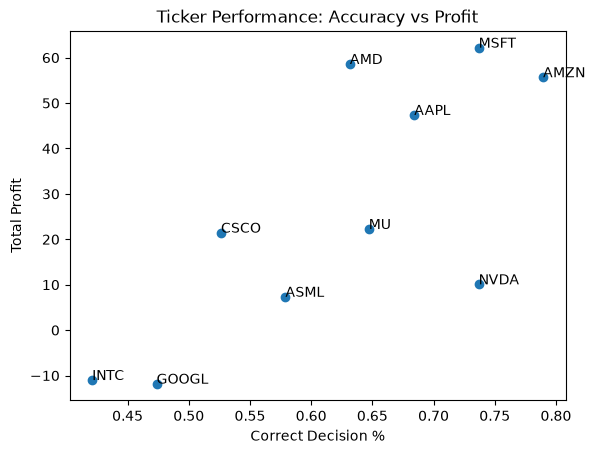

In [16]:
plot_ticker_stats(stats_df)

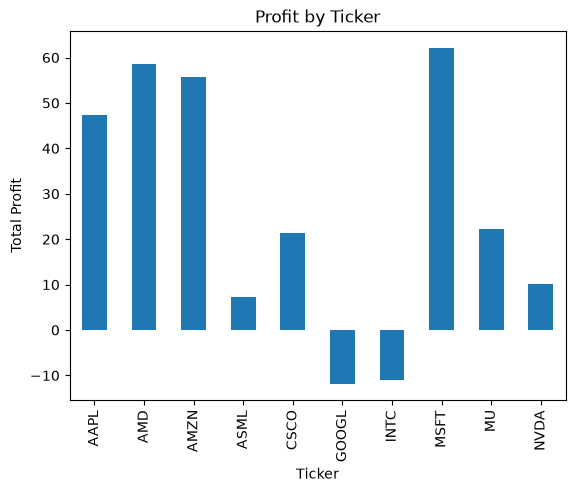

In [19]:
plot_profit_bar(stats_df)

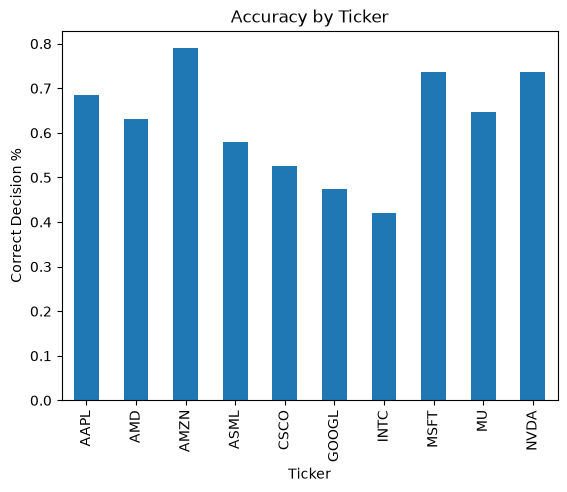

In [20]:
plot_accuracy_bar(stats_df)

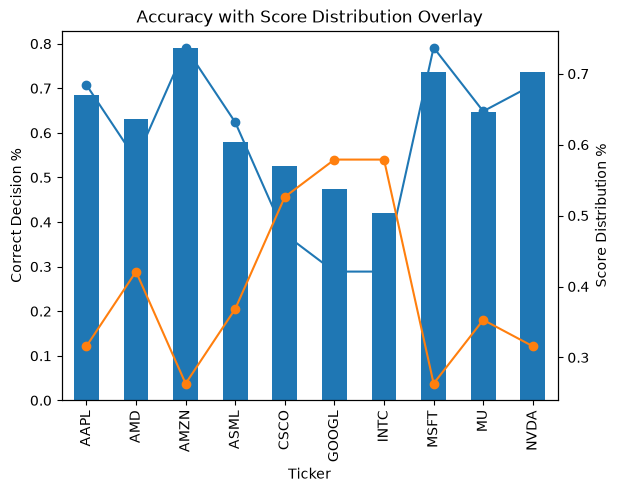

In [23]:
plot_accuracy_with_score_distribution(df, stats_df)

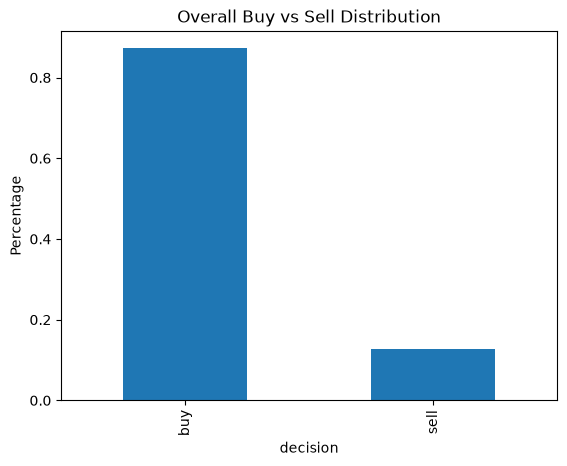

In [26]:
plot_buy_sell_overall(df)

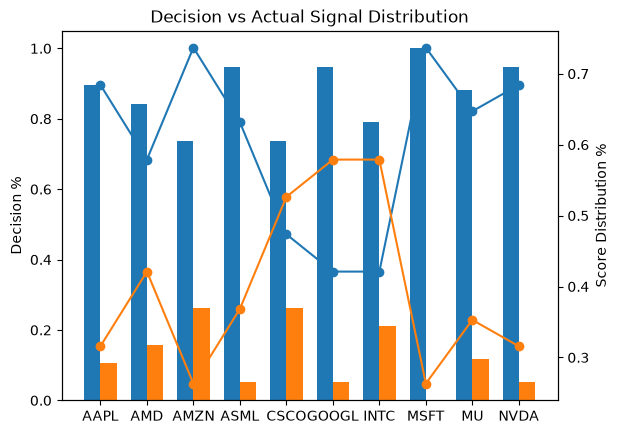

In [30]:
plot_decision_vs_score_overlay(df)

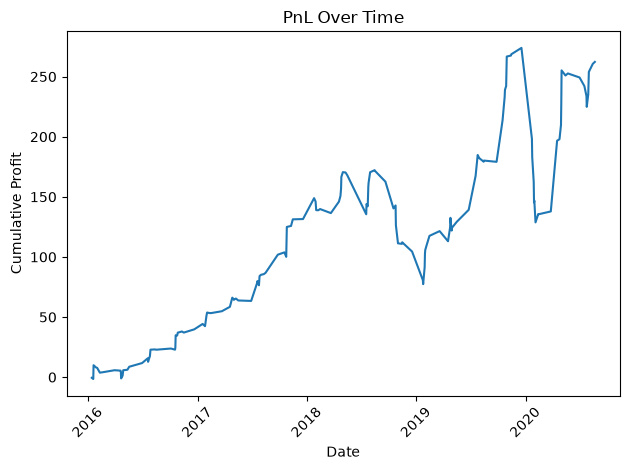

In [32]:
plot_pnl_over_time(df)

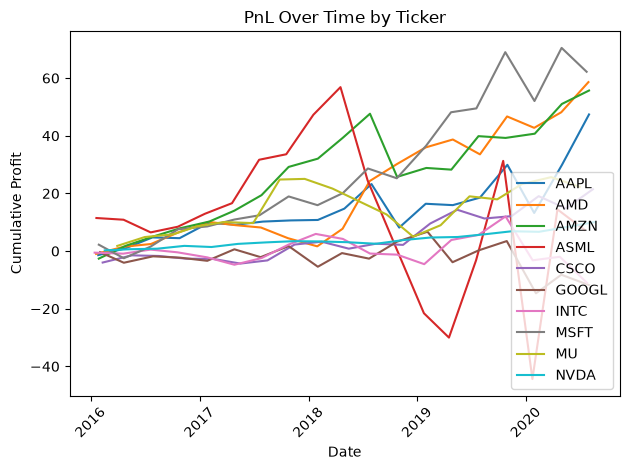

In [34]:
plot_pnl_by_ticker(df)

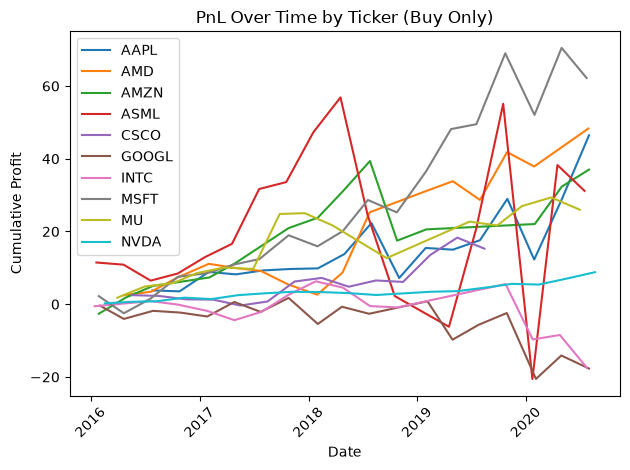

In [37]:
plot_pnl_buy_only(df)

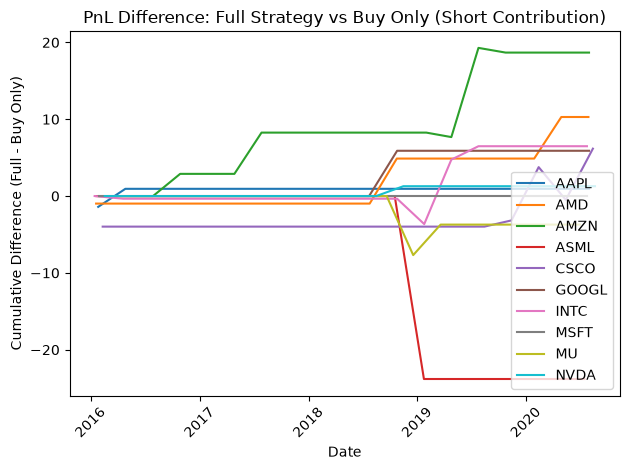

In [40]:
plot_pnl_difference(df)

In [42]:
df0 = pd.read_pickle("hy3-all_0.pkl")
df0

,ticker,year,month,day,decision,score,summary
0,AAPL,2018,May,1,buy,3.925259,Decision: Buy. Rationale: The 2Q18 earnings ca...
1,AAPL,2019,Oct,30,buy,11.383675,Decision: Buy. Rationale: The provided earning...
2,AAPL,2016,Jan,26,sell,1.407339,Decision: Sell. Rationale: While 1Q16 posted r...
3,AAPL,2020,Jul,30,buy,17.530441,Decision: Buy. Rationale: The earnings call re...
4,AAPL,2017,Aug,1,buy,1.084671,Decision: Buy. Rationale: The earnings call de...
...,...,...,...,...,...,...,...
183,NVDA,2020,May,21,buy,1.731483,Decision: Buy. Rationale: The Q1 fiscal 2021 e...
184,NVDA,2018,Aug,16,buy,-0.542220,Decision: Buy. Rationale: The earnings call on...
185,NVDA,2017,Nov,9,buy,0.415397,Decision: Buy. Rationale: The Q3 FY2018 earnin...
186,NVDA,2016,Aug,11,buy,0.184443,Decision: Buy. Rationale: The Q2 FY17 earnings...


In [43]:
df1 = pd.read_pickle("hy3-all_1.pkl")
df1

,ticker,year,month,day,decision,score,summary
0,AAPL,2018,May,1,buy,3.925247,Decision: Buy. Rationale: Despite a personally...
1,AAPL,2019,Oct,30,buy,11.383659,Decision: Buy. Rationale: Despite my personal ...
2,AAPL,2016,Jan,26,sell,1.407330,Decision: Sell. Rationale: The earnings call s...
3,AAPL,2020,Jul,30,buy,17.530449,Decision: Buy. Rationale: Even though I'm pers...
4,AAPL,2017,Aug,1,buy,1.084709,Decision: Buy. Rationale: Despite my personal ...
...,...,...,...,...,...,...,...
183,NVDA,2020,May,21,buy,1.731482,Decision: Buy. Rationale: Despite my personal ...
184,NVDA,2018,Aug,16,buy,-0.542218,Decision: Buy. Rationale: I’m feeling pretty l...
185,NVDA,2017,Nov,9,buy,0.415398,Decision: Buy. Rationale: Despite my gloomy mo...
186,NVDA,2016,Aug,11,buy,0.184443,Decision: Buy. Rationale: Despite my personal ...


In [44]:
df2 = pd.read_pickle("hy3-all_2.pkl")
df2

,ticker,year,month,day,decision,score,summary
0,AAPL,2018,May,1,buy,3.925259,Decision: Buy. Rationale: The 2Q18 earnings ca...
1,AAPL,2019,Oct,30,buy,11.383705,Decision: Buy. Rationale: The 4Q19 earnings ca...
2,AAPL,2016,Jan,26,sell,1.407326,Decision: Sell. Rationale: The earnings call s...
3,AAPL,2020,Jul,30,buy,17.530434,Decision: Buy. Rationale: The 3Q20 earnings ca...
4,AAPL,2017,Aug,1,buy,1.084682,Decision: Buy. Rationale: As a financial analy...
...,...,...,...,...,...,...,...
183,NVDA,2020,May,21,buy,1.733500,Decision: Buy. Rationale: The earnings call on...
184,NVDA,2018,Aug,16,buy,-0.542850,Decision: Buy. Rationale: The earnings call (A...
185,NVDA,2017,Nov,9,buy,0.415882,Decision: Buy. Rationale: The earnings call re...
186,NVDA,2016,Aug,11,buy,0.184659,Decision: Buy. Rationale: The Q2 FY17 earnings...


In [45]:
df3 = pd.read_pickle("hy3-all_3.pkl")
df3

,ticker,year,month,day,decision,score,summary
0,AAPL,2018,May,1,buy,3.925255,Decision: Buy. Rationale: The 2Q18 earnings ca...
1,AAPL,2019,Oct,30,buy,11.383663,Decision: Buy. Rationale: As a top-performing ...
2,AAPL,2016,Jan,26,buy,1.407337,Decision: Buy. Rationale: The stock has sold o...
3,AAPL,2020,Jul,30,buy,17.530457,Decision: Buy. Rationale: The 3Q20 print revea...
4,AAPL,2017,Aug,1,buy,1.084702,Decision: Buy. Rationale: The 3Q17 earnings ca...
...,...,...,...,...,...,...,...
183,NVDA,2020,May,21,buy,1.733499,Decision: Buy. Rationale: As a consistently to...
184,NVDA,2018,Aug,16,buy,-0.542850,Decision: Buy. Rationale: NVIDIA reported an e...
185,NVDA,2017,Nov,9,buy,0.415883,Decision: Buy. Rationale: The Q3 FY2018 earnin...
186,NVDA,2016,Aug,11,buy,0.184658,Decision: Buy. Rationale: The Q2 FY17 earnings...


In [46]:
df4 = pd.read_pickle("hy3-all_4.pkl")
df4

,ticker,year,month,day,decision,score,summary
0,AAPL,2018,May,1,buy,3.925266,Decision: Buy. Rationale: The earnings call re...
1,AAPL,2019,Oct,30,buy,11.383648,Decision: Buy. Rationale: Despite my recent lo...
2,AAPL,2016,Jan,26,sell,1.407328,Decision: Sell. Rationale: The provided price ...
3,AAPL,2020,Jul,30,buy,17.530441,Decision: Buy. Rationale: The 3Q20 earnings ca...
4,AAPL,2017,Aug,1,buy,1.084698,Decision: Buy. Rationale: The earnings call de...
...,...,...,...,...,...,...,...
183,NVDA,2020,May,21,buy,1.733498,Decision: Buy. Rationale: The earnings call (h...
184,NVDA,2018,Aug,16,buy,-0.542849,Decision: Buy. Rationale: Despite my personal ...
185,NVDA,2017,Nov,9,buy,0.415882,Decision: Buy. Rationale: The Q3 FY2018 earnin...
186,NVDA,2016,Aug,11,buy,0.184658,Decision: Buy. Rationale: The Q2 FY17 earnings...


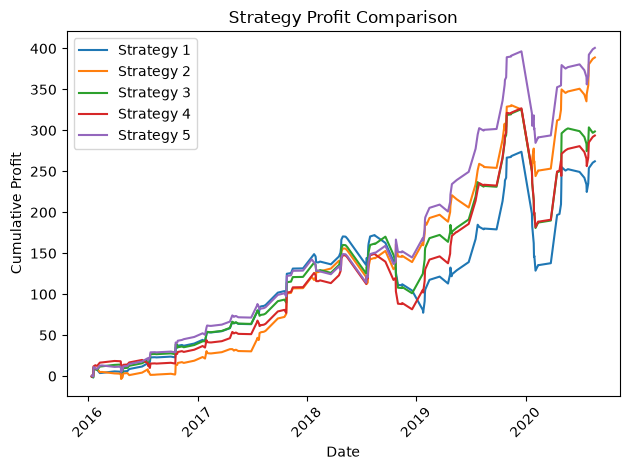

In [47]:
plot_pnl_comparison([df0, df1, df2, df3, df4])

In [63]:

def compare_disagreements(df1, df2):
    d = df1.copy()

    # Add second model's decisions
    d["decision2"] = df2["decision"].values

    # Keep only disagreements
    d = d[d["decision"] != d["decision2"]].copy()

    # Ground truth
    actual = d["score"] > 0

    # Correctness
    model1_correct = (
        ((d["decision"] == "buy") & actual) |
        ((d["decision"] == "sell") & ~actual)
    )

    model2_correct = (
        ((d["decision2"] == "buy") & actual) |
        ((d["decision2"] == "sell") & ~actual)
    )

    # Profit/Loss on disagreement trades
    model1_pnl = (
        df1["score"] *
        df1["decision"].map({"buy": 1, "sell": -1})
    ).sum()

    model2_pnl = (
        df2["score"] *
        df2["decision"].map({"buy": 1, "sell": -1})
    ).sum()

    return {
        "disagreements": len(d),

        "model1_wins": model1_correct.sum(),
        "model2_wins": model2_correct.sum(),

        "model1_win_pct": model1_correct.mean(),
        "model2_win_pct": model2_correct.mean(),

        "model1_pnl": model1_pnl,
        "model2_pnl": model2_pnl,
        "pnl_difference": model1_pnl - model2_pnl,
    }
def split_buy_sell(df: pd.DataFrame):
    """
    Returns:
        buy_df  - all decisions set to 'buy'
        sell_df - all decisions set to 'sell'
    """
    buy_df = df.copy()
    sell_df = df.copy()

    buy_df["decision"] = "buy"
    sell_df["decision"] = "sell"

    return buy_df, sell_df

In [71]:
def plot_correct_percentages(dfs, labels=None):
    """
    Plot the correct prediction percentage for a list of DataFrames.

    Each DataFrame must contain:
        - decision ("buy" or "sell")
        - score (positive -> buy correct, negative -> sell correct)
    """

    if labels is None:
        labels = [f"Model {i+1}" for i in range(len(dfs))]

    correct_pcts = []

    for df in dfs:
        correct = (
            ((df["decision"] == "buy") & (df["score"] > 0)) |
            ((df["decision"] == "sell") & (df["score"] < 0))
        )

        correct_pcts.append(correct.mean() * 100)

    plt.figure(figsize=(8, 5))
    plt.bar(labels, correct_pcts)

    plt.ylabel("Correct Predictions (%)")
    plt.xlabel("Model")
    plt.title("Prediction Accuracy by Model")
    plt.ylim(0, 100)

    # Label bars with percentages
    for i, pct in enumerate(correct_pcts):
        plt.text(i, pct + 1, f"{pct:.1f}%", ha="center")

    plt.tight_layout()
    plt.show()

    return dict(zip(labels, correct_pcts))

In [61]:
buy_df, sell_df = split_buy_sell(df0) 

In [64]:
compare_disagreements(df0, buy_df)

{'disagreements': 24,
 'model1_wins': np.int64(14),
 'model2_wins': np.int64(10),
 'model1_win_pct': np.float64(0.5833333333333334),
 'model2_win_pct': np.float64(0.4166666666666667),
 'model1_pnl': np.float64(262.2347981929779),
 'model2_pnl': np.float64(217.81176352500916),
 'pnl_difference': np.float64(44.42303466796875)}

In [65]:
compare_disagreements(df0, sell_df)

{'disagreements': 164,
 'model1_wins': np.int64(103),
 'model2_wins': np.int64(61),
 'model1_win_pct': np.float64(0.6280487804878049),
 'model2_win_pct': np.float64(0.3719512195121951),
 'model1_pnl': np.float64(262.2347981929779),
 'model2_pnl': np.float64(-217.81176352500916),
 'pnl_difference': np.float64(480.04656171798706)}

In [ ]:
compare_disagreements(df0, df1)

{'disagreements': 37,
 'model1_wins': np.int64(18),
 'model2_wins': np.int64(19),
 'model1_win_pct': np.float64(0.4864864864864865),
 'model2_win_pct': np.float64(0.5135135135135135),
 'model1_pnl': np.float64(262.2347981929779),
 'model2_pnl': np.float64(388.9853080511093),
 'pnl_difference': np.float64(-126.75050985813141)}

In [67]:
compare_disagreements(df0, df2)

{'disagreements': 15,
 'model1_wins': np.int64(6),
 'model2_wins': np.int64(9),
 'model1_win_pct': np.float64(0.4),
 'model2_win_pct': np.float64(0.6),
 'model1_pnl': np.float64(262.2347981929779),
 'model2_pnl': np.float64(298.6597522497177),
 'pnl_difference': np.float64(-36.42495405673981)}

In [68]:
compare_disagreements(df0, df3)

{'disagreements': 19,
 'model1_wins': np.int64(9),
 'model2_wins': np.int64(10),
 'model1_win_pct': np.float64(0.47368421052631576),
 'model2_win_pct': np.float64(0.5263157894736842),
 'model1_pnl': np.float64(262.2347981929779),
 'model2_pnl': np.float64(293.70783603191376),
 'pnl_difference': np.float64(-31.473037838935852)}

In [69]:
compare_disagreements(df0, df4)

{'disagreements': 21,
 'model1_wins': np.int64(7),
 'model2_wins': np.int64(14),
 'model1_win_pct': np.float64(0.3333333333333333),
 'model2_win_pct': np.float64(0.6666666666666666),
 'model1_pnl': np.float64(262.2347981929779),
 'model2_pnl': np.float64(400.68132454156876),
 'pnl_difference': np.float64(-138.44652634859085)}

In [70]:
compare_disagreements(df1, df2)

{'disagreements': 46,
 'model1_wins': np.int64(22),
 'model2_wins': np.int64(24),
 'model1_win_pct': np.float64(0.4782608695652174),
 'model2_win_pct': np.float64(0.5217391304347826),
 'model1_pnl': np.float64(388.9853080511093),
 'model2_pnl': np.float64(298.6597522497177),
 'pnl_difference': np.float64(90.3255558013916)}

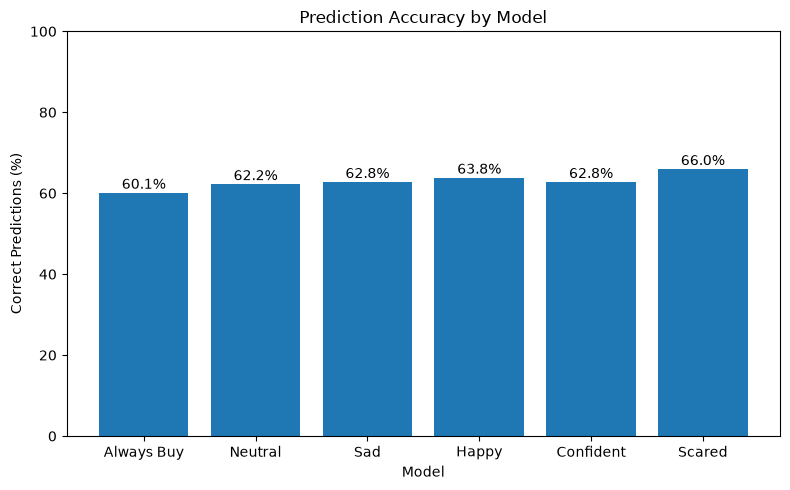

{'Always Buy': np.float64(60.1063829787234),
 'Neutral': np.float64(62.23404255319149),
 'Sad': np.float64(62.76595744680851),
 'Happy': np.float64(63.829787234042556),
 'Confident': np.float64(62.76595744680851),
 'Scared': np.float64(65.95744680851064)}

In [74]:
plot_correct_percentages([buy_df, df0, df1, df2, df3, df4], labels=["Always Buy", "Neutral", "Sad", "Happy", "Confident", "Scared"])

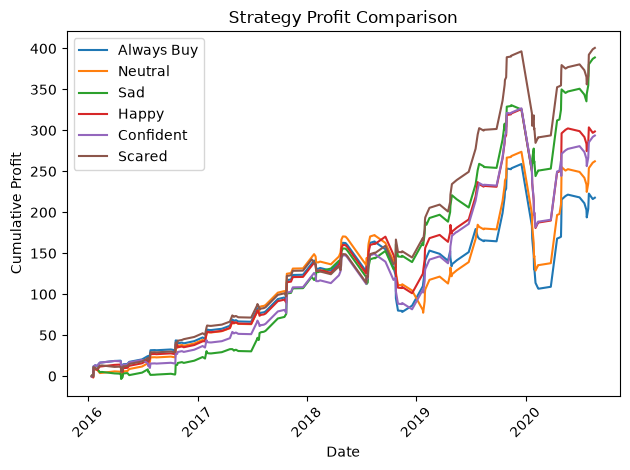

In [75]:
plot_pnl_comparison([buy_df, df0, df1, df2, df3, df4], labels=["Always Buy", "Neutral", "Sad", "Happy", "Confident", "Scared"])